In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from linear_models import fit_ols, fit_ridge, fit_lasso, predict_ols, predict_ridge, predict_lasso

In [2]:
rng = np.random.default_rng(seed=42)
n_samples = 80

# x1 et x2 sont très corrélés, x3 est un bruit inutile
x1 = rng.standard_normal((n_samples, 1))
x2 = x1 + rng.standard_normal((n_samples, 1)) * 0.005
x3 = rng.standard_normal((n_samples, 1))

X = np.hstack((x1, x2, x3))

# Vrais poids théoriques du marché : l'intercept vaut 4.0, x1 vaut 3.0, x2 vaut 1.5, x3 vaut 0.0
true_intercept = 4.0
true_beta = np.array([3.0, 1.5, 0.0])

Y = true_intercept + (X @ true_beta).reshape(-1, 1) + rng.standard_normal((n_samples, 1)) * 1.0

In [3]:
# 1. Ajustement OLS
beta_ols = fit_ols(X, Y, fit_intercept=True)

# 2. Ajustement Ridge
beta_ridge = fit_ridge(X, Y, lam=15.0, fit_intercept=True)

# 3. Ajustement Lasso
intercept_lasso, beta_lasso = fit_lasso(X, Y.flatten(), lam=0.1)
# On package l'intercept et les coefficients lasso ensemble pour l'affichage
poids_lasso = np.hstack(([intercept_lasso], beta_lasso))

print("="*65)
print("--- TABLEAU COMPARATIF DES POIDS ESTIMÉS ---")
print("="*65)
print(f"Vrais paramètres d'origine :  [{true_intercept},  3.0,  1.5,  0.0]")
print(f"Coefficients calculés par OLS :    {beta_ols.flatten().round(3)}")
print(f"Coefficients calculés par Ridge :  {beta_ridge.flatten().round(3)}")
print(f"Coefficients calculés par Lasso :  {poids_lasso.round(3)}")
print("="*65)

--- TABLEAU COMPARATIF DES POIDS ESTIMÉS ---
Vrais paramètres d'origine :  [4.0,  3.0,  1.5,  0.0]
Coefficients calculés par OLS :    [ 4.0630e+00  1.9082e+01 -1.4901e+01 -2.0000e-03]
Coefficients calculés par Ridge :  [ 4.090e+00  1.799e+00  1.799e+00 -4.000e-03]
Coefficients calculés par Lasso :  [4.079 4.    0.    0.   ]


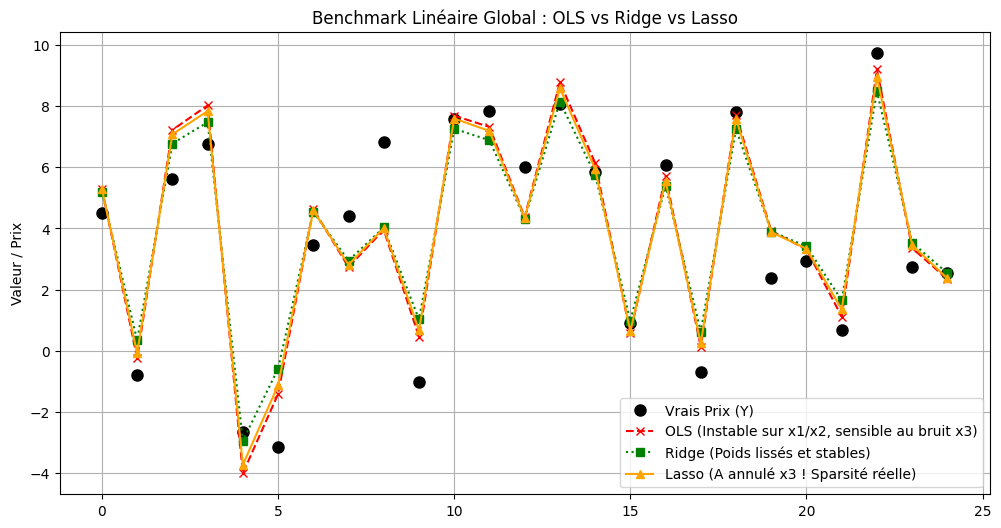

In [4]:
Y_pred_ols = predict_ols(X, beta_ols, fit_intercept=True)
Y_pred_ridge = predict_ridge(X, beta_ridge, fit_intercept=True)
Y_pred_lasso = predict_lasso(X, intercept_lasso, beta_lasso)

plt.figure(figsize=(12, 6))
plt.plot(Y[:25], label="Vrais Prix (Y)", marker='o', color='black', linestyle='none', markersize=8)
plt.plot(Y_pred_ols[:25], label="OLS (Instable sur x1/x2, sensible au bruit x3)", marker='x', color='red', linestyle='--')
plt.plot(Y_pred_ridge[:25], label="Ridge (Poids lissés et stables)", marker='s', color='green', linestyle=':')
plt.plot(Y_pred_lasso[:25], label="Lasso (A annulé x3 ! Sparsité réelle)", marker='^', color='orange', linestyle='-')

plt.title("Benchmark Linéaire Global : OLS vs Ridge vs Lasso")
plt.ylabel("Valeur / Prix")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
" OLS "

# 1. Ne pas utiliser np.random.seed() (Le piège de l'état global)
# --> Cette méthode est dite "legacy" (obsolète) dans NumPy
# --> Elle modifie l'état aléatoire global de toute ton application Python. 
# --> Si un autre script s'exécute en parallèle sur le même serveur, les deux codes vont interférer, brisant la reproductibilité.

# Solution :
# np.random.default_rng()
# --> plus rapide, plus sûr, et cela isole tes simulations 
# --> indispensable pour les simulations de Monte Carlo massives


# 2. Privilégier la clarté de construction matricielle plutôt que les raccourcis syntaxiques
# --> Le problème en production : np.c_ (et son jumeau np.r_) 

# Solution : 
# np.hstack() (horizontal stack) ou np.concatenate()
# --> Le code devient immédiatement auto-documenté.


# 3. Ne jamais inverser une matrice avec np.linalg.inv()
# --> opération lourde et numériquement instable (surtout si mauvais conditionnement)
# --> erreurs d'arrondi qui peuvent faire planter le code

# Solution : 
# A = X_t @ X_b
# b = X_t @ Y
# return np.linalg.solve(A, b)
# --> Utilise décomposition LU, Cholesky
# --> beaucoup plus stable et rapide


# 4. Lisibilité des opérations matricielles
# Utiliser l'opérateur @
# --> au lieu de A.dot(B).dot(C), on écrit A @ B @ C

In [ ]:
" RIDGE "

# 1. Pourquoi utiliser Ridge plutôt qu'OLS en Finance ?
# --> Le problème de la multi-colinéarité :
# --> Sur les marchés, de nombreux facteurs explicatifs sont fortement corrélés entre eux 
# ex : les rendements de deux indices du même secteur, ou différentes maturités de taux d'intérêt). 
# --> Face à des variables colinéaires, la matrice X^T*X de l'OLS devient quasi-singulière, ce qui fait exploser la variance des coefficients beta. 
# --> Le modèle devient instable et hypersensible au bruit de marché.

# La solution Ridge :
# --> La pénalité L2 force artificiellement la matrice à être bien conditionnée (inversible de manière stable). 
# --> Les coefficients beta sont contraints (shrinkage), ce qui réduit drastiquement la variance des prédictions au prix d'un biais minime.


# 2. Pourquoi ne pénalise-t-on pas l'intercept (I[0, 0] = 0) ?
# --> Principe de régularisation : L'intercept (beta_0) représente la valeur centrale ou moyenne de la cible Y lorsque toutes les variables explicatives sont nulles. 
# --> Pénaliser beta_0 reviendrait à forcer la moyenne de nos prédictions à se rapprocher de zéro, ce qui n'a pas de sens économique.

# Mise en œuvre :
# --> Dans le code, on s'assure que l'élément top-gauche de notre matrice identité de pénalisation vaut explicitement `0` pour laisser l'intercept s'ajuster librement.

In [ ]:
" LASSO "

# 1. La force du LASSO en Finance : La Sélection de Variables
# Le concept de Sparsité :
# --> Contrairement à la régression Ridge qui réduit la valeur des coefficients sans jamais les annuler, la pénalité L_1 du LASSO génère de la sparsité 
# --> des poids exactement égaux à 0.0 
# --> Mathématiquement, la zone de contrainte du LASSO possède des "coins" pointus sur les axes, augmentant la probabilité géométrique que la solution touche un axe.

# Utilité Quant : C'est un outil formidable pour le *Feature Selection*. 
# --> Si un modèle contient 50 signaux alternatifs, le LASSO permet d'éliminer automatiquement les signaux redondants ou simples bruits de marché pour ne garder que les facteurs ayant une vraie valeur prédictive.


# 2. Algorithme de Descente par Coordonnées vs Équation Normale
# Pas de solution analytique
# --> La fonction valeur absolue de la pénalité L_1 n'est pas dérivable en zéro. 
# --> Impossible de poser une équation normale comme pour l'OLS ou Ridge.

# Alternative robuste : On utilise la Descente par Coordonnées. 
# --> L'algorithme optimise le modèle une seule variable à la fois en fixant toutes les autres. 
# --> Utilisation de l'opérateur de seuillage doux (`soft thresholding`) permet de décider de manière itérative si la variable mérite d'être conservée ou mise à zéro.